In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Loading the downloaded dataset 
file_path = r'D:\student performance analyzer\archive\StudentsPerformance.csv'
df = pd.read_csv(file_path)
# For summary of dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [34]:
# Checking missing value for Data Cleaning
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [35]:
# Finding Average of all three subject individually
math_avg = df['math score'].mean()
reading_avg = df['reading score'].mean()
writing_avg = df['writing score'].mean()

print(f"Math Average: {math_avg:.2f}")
print(f"Reading Average: {reading_avg:.2f}")
print(f"Writing Average: {writing_avg:.2f}")

Math Average: 66.09
Reading Average: 69.17
Writing Average: 68.05


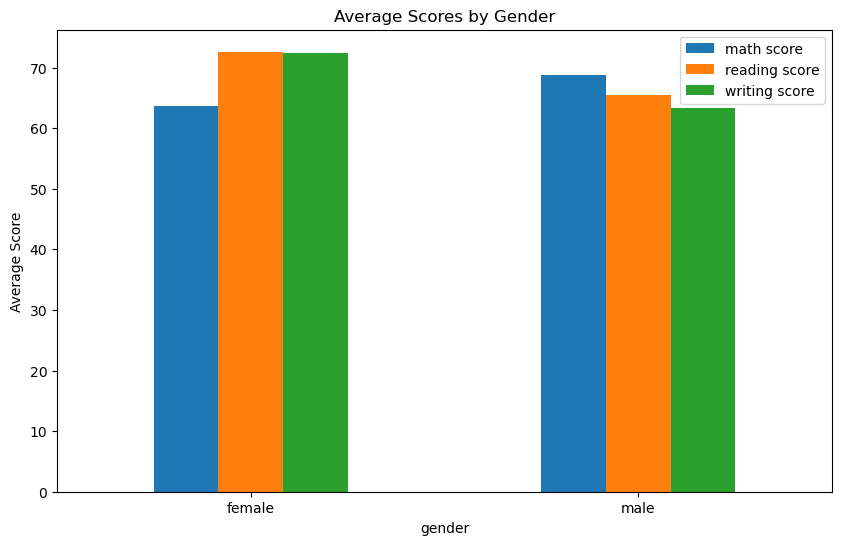

In [36]:
# plotting a graph of average score by gender
gender_group = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

gender_group.plot(kind='bar', figsize=(10, 6))
plt.title('Average Scores by Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

In [37]:
# Adding average score of students for comparison
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [38]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [39]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'average_score'],
      dtype='object')

Top performing segments based on Parental Education:
parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


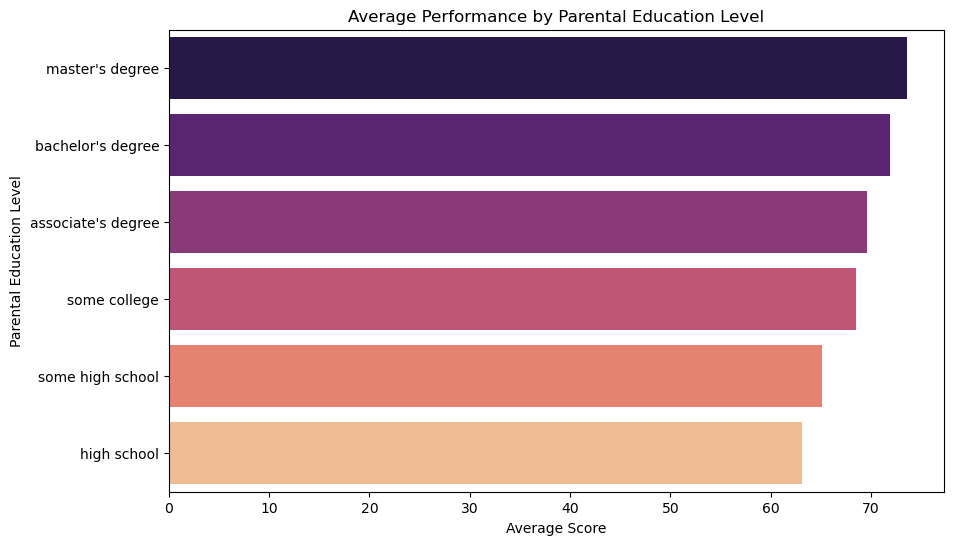

In [40]:
# Grouping by multiple factors to identify high-performing segments
# 1. Parental level of education vs Average score
top_groups = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False)

print("Top performing segments based on Parental Education:")
print(top_groups)

# 2. Visualization of these groups
plt.figure(figsize=(10, 6))
sns.barplot(x=top_groups.values, y=top_groups.index, hue=top_groups.index, palette='magma', legend=False,)
plt.title('Average Performance by Parental Education Level')
plt.xlabel('Average Score')
plt.ylabel('Parental Education Level')
plt.show()

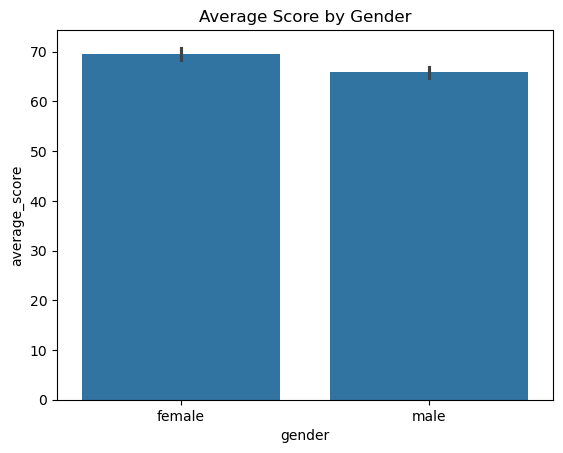

In [41]:
# graph of combined average score by gender
sns.barplot(x='gender', y='average_score', data=df)
plt.title('Average Score by Gender')
plt.show()

In [42]:
# filtering top performing students which has a greater average score than 95
top_performers = df[df['average_score'] > 95]
top_performers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
106,female,group D,master's degree,standard,none,87,100,100,95.666667
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
179,female,group D,some high school,standard,completed,97,100,100,99.000000
403,female,group D,high school,standard,completed,88,99,100,95.666667
451,female,group E,some college,standard,none,100,92,97,96.333333
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
546,female,group A,some high school,standard,completed,92,100,97,96.333333
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100,97.333333


In [43]:
# finding average performance based on parental education level
df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False)

parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64

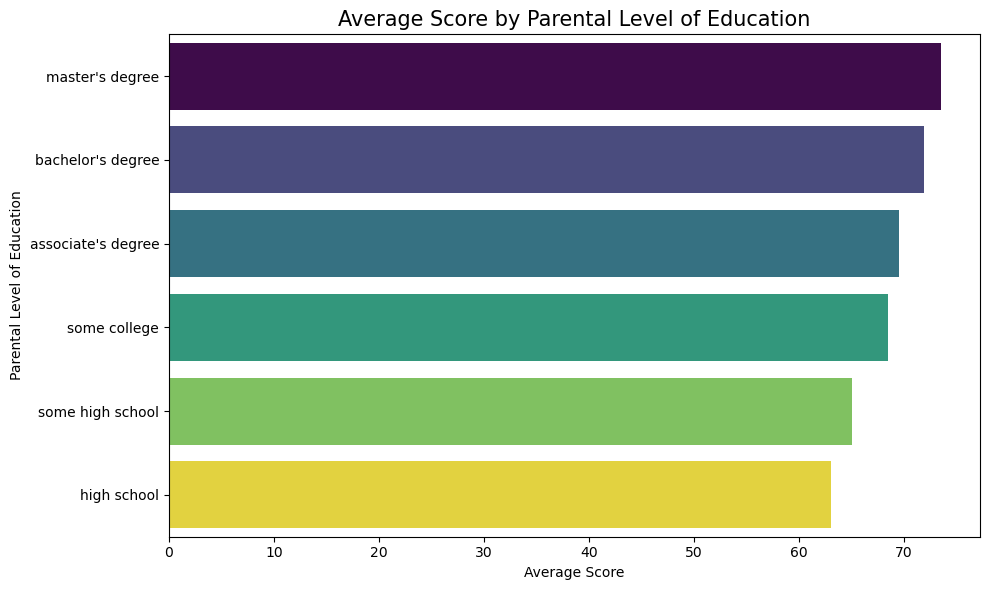

In [44]:
# 1. Group the data by parental education and sort by average score to see the trends clearly
grouped_data = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False).reset_index()

# 2. Creating a bar chart to visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='average_score', y='parental level of education', data=grouped_data, hue=grouped_data.index, palette='viridis', legend=False,)

# 3. Adding chart and lables to make the chart easily understandable
plt.title('Average Score by Parental Level of Education', fontsize=15)
plt.xlabel('Average Score')
plt.ylabel('Parental Level of Education')

# 4. To display chart
plt.tight_layout()
plt.show()